In [1]:
import json
import math
import os
import gc
import itertools
import random
from functools import partial
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.datasets import ImageFolder

from torchvision.models import wide_resnet101_2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score
)

In [2]:
SEED = 42

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
tf.config.optimizer.set_jit(False)

In [3]:
import torch
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)

cuda


In [4]:
def Dataset_loader_recursive(DIR, RESIZE):
    IMG = []
    
    for root, _, files in os.walk(DIR):
        for file in files:
            PATH = os.path.join(root, file)
            _, ftype = os.path.splitext(PATH)
            
            if ftype.lower() in [".jpg", ".jpeg", ".png"]:
                try:
                    img = np.asarray(Image.open(PATH).convert("RGB"))
                    img = cv2.resize(img, (RESIZE, RESIZE))
                    IMG.append(img)
                except:
                    continue
    
    return np.array(IMG)
DIR = "/kaggle/input/datasets/tueoban/aisslab-breast-cancer-sub-datasets/AISSLab Sub-datasets/Raw Sub-datasets/AISSLab-v5"

benign_bi_rads_2 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 2"), RESIZE=224)
benign_bi_rads_3 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 3"), RESIZE=224)

malignant_bi_rads_4 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 4"), RESIZE=224)
malignant_bi_rads_5 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 5"), RESIZE=224)

#normal = Dataset_loader_recursive(os.path.join(DIR, "Normal/JPG/"), RESIZE=224)

In [5]:
print("Total images loaded:", len(benign_bi_rads_2))
print("Shape:", benign_bi_rads_2.shape)

print("Total images loaded:", len(benign_bi_rads_3))
print("Shape:", benign_bi_rads_3.shape)

print("Total images loaded:", len(malignant_bi_rads_4))
print("Shape:", malignant_bi_rads_4.shape)

print("Total images loaded:", len(malignant_bi_rads_5))
print("Shape:", malignant_bi_rads_5.shape)

Total images loaded: 18
Shape: (18, 224, 224, 3)
Total images loaded: 48
Shape: (48, 224, 224, 3)
Total images loaded: 54
Shape: (54, 224, 224, 3)
Total images loaded: 46
Shape: (46, 224, 224, 3)


In [6]:
#normal_label = np.full(len(normal),0)
benign_bi_rads_2_label = np.full(len(benign_bi_rads_2), 0)
benign_bi_rads_3_label = np.full(len(benign_bi_rads_3),1)
malignant_bi_rads_4_label = np.full(len(malignant_bi_rads_4),2)
malignant_bi_rads_5_label = np.full(len(malignant_bi_rads_5),3)

In [7]:
X = np.concatenate((benign_bi_rads_2, benign_bi_rads_3, malignant_bi_rads_4, malignant_bi_rads_5), axis = 0)
Y = np.concatenate((benign_bi_rads_2_label, benign_bi_rads_3_label, malignant_bi_rads_4_label, malignant_bi_rads_5_label), axis = 0)

# Shuffle train data
s = np.arange(X.shape[0])
np.random.shuffle(s)
X = X[s]
Y = Y[s]


X = X.astype(np.float32)

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    random_state=11,
    stratify=Y
)

In [8]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, 
    test_size=0.2, 
    random_state=11,
    stratify=y_train
)
print("\nFinal Shapes:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)


Final Shapes:
x_train: (105, 224, 224, 3)
y_train: (105,)
x_val: (27, 224, 224, 3)
y_val: (27,)
x_test: (34, 224, 224, 3)
y_test: (34,)


In [9]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import numpy as np

print("Original class distribution:")
print(Counter(y_train))

# Flatten image data
nsamples, h, w, c = x_train.shape

x_train_flat = x_train.reshape(
    (nsamples, h * w * c)
)

target = 3000

sampling_strategy = {
    0: target,
    1: target,
    2: target,
    3: target
}

ros = RandomOverSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

x_train, y_train = ros.fit_resample(
    x_train_flat,
    y_train
)

# Restore shape
x_train = x_train.reshape(
    (-1, h, w, c)
)

print("\nBalanced class distribution:")
print(Counter(y_train))

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

Original class distribution:
Counter({np.int64(2): 34, np.int64(3): 30, np.int64(1): 30, np.int64(0): 11})

Balanced class distribution:
Counter({np.int64(2): 3000, np.int64(3): 3000, np.int64(0): 3000, np.int64(1): 3000})
x_train: (12000, 224, 224, 3)
y_train: (12000,)


In [10]:
# Using original generator
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0,translate=(0.2, 0.2),shear=20),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

BATCH_SIZE = 32

In [11]:
model = wide_resnet101_2(weights='IMAGENET1K_V1')
print(model)

Downloading: "https://download.pytorch.org/models/wide_resnet101_2-32ee1156.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet101_2-32ee1156.pth


100%|██████████| 243M/243M [00:01<00:00, 215MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), strid

In [12]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features,4)

model = model.to(device)
print(model.fc)

Linear(in_features=2048, out_features=4, bias=True)


In [13]:
# Freeze all
for param in model.parameters():
    param.requires_grad = False

# Train only FC
for param in model.fc.parameters():
    param.requires_grad = True

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=5e-5
)

In [15]:
from torch.utils.data import Dataset

class BreastDataset(Dataset):

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform:
            image = self.transform(image)
        label = int(self.labels[idx])

        return image, label

In [16]:
from torch.utils.data import DataLoader

train_dataset = BreastDataset(
    x_train,
    y_train,
    transform=train_transform
)

val_dataset = BreastDataset(
    x_val,
    y_val,
    transform=val_transform
)

test_dataset = BreastDataset(
    x_test,
    y_test,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 375
Val batches: 1
Test batches: 2


In [17]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [18]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [19]:
EPOCHS = 50

best_acc = 0
patience = 8
counter = 0

for epoch in range(EPOCHS):
    
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    # TRAIN
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    # VALIDATION
    model.eval()

    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # METRICS
    val_acc = 100 * correct / total

    train_acc = 100 * train_correct / train_total

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # LR Scheduler
    scheduler.step(val_loss)

    # Save Best Model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(
            model.state_dict(),
            "/kaggle/working/wideresnet101_best_final.pth"
        )

        counter = 0
    else:
        counter += 1

    # Early Stopping
    if counter >= patience:
        print("Early stopping")
        break

Epoch 1/50 | Train Loss: 1.3117 | Val Loss: 1.3205 | Train Acc: 41.05% | Val Acc: 25.93%
Epoch 2/50 | Train Loss: 1.2011 | Val Loss: 1.3290 | Train Acc: 54.27% | Val Acc: 29.63%
Epoch 3/50 | Train Loss: 1.1320 | Val Loss: 1.3032 | Train Acc: 58.58% | Val Acc: 33.33%
Epoch 4/50 | Train Loss: 1.0757 | Val Loss: 1.3685 | Train Acc: 61.62% | Val Acc: 25.93%
Epoch 5/50 | Train Loss: 1.0324 | Val Loss: 1.3399 | Train Acc: 63.62% | Val Acc: 29.63%
Epoch 6/50 | Train Loss: 0.9965 | Val Loss: 1.3634 | Train Acc: 64.45% | Val Acc: 22.22%
Epoch 7/50 | Train Loss: 0.9687 | Val Loss: 1.3380 | Train Acc: 66.43% | Val Acc: 18.52%
Epoch 8/50 | Train Loss: 0.9441 | Val Loss: 1.3596 | Train Acc: 67.92% | Val Acc: 37.04%
Epoch 9/50 | Train Loss: 0.9358 | Val Loss: 1.3671 | Train Acc: 68.03% | Val Acc: 25.93%
Epoch 10/50 | Train Loss: 0.9340 | Val Loss: 1.3329 | Train Acc: 67.77% | Val Acc: 37.04%
Epoch 11/50 | Train Loss: 0.9231 | Val Loss: 1.3653 | Train Acc: 68.78% | Val Acc: 29.63%
Epoch 12/50 | Train

In [20]:
model.load_state_dict(torch.load("/kaggle/working/wideresnet101_best_final.pth"))
print("Best FC model loaded")

Best FC model loaded


In [21]:
# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.fc.parameters():
    param.requires_grad = True

In [22]:
# RECOMPILE
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

In [23]:
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [24]:
EPOCHS = 100

best_acc = 0
patience = 8
counter = 0

for epoch in range(EPOCHS):

    # TRAIN
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    # VALIDATION
    model.eval()

    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # METRICS
    val_acc = 100 * correct / total

    train_acc = 100 * train_correct / train_total

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # LR Scheduler
    scheduler.step(val_loss)

    # Save Best Model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(
            model.state_dict(),
            "/kaggle/working/wideresnet101_best_final.pth"
        )
        counter = 0

    else:
        counter += 1

    # Early Stopping
    if counter >= patience:
        print("Early stopping")
        break

Epoch 1/100 | Train Loss: 0.3478 | Val Loss: 1.5019 | Train Acc: 91.16% | Val Acc: 44.44%
Epoch 2/100 | Train Loss: 0.0481 | Val Loss: 1.9639 | Train Acc: 99.45% | Val Acc: 44.44%
Epoch 3/100 | Train Loss: 0.0207 | Val Loss: 2.3259 | Train Acc: 99.68% | Val Acc: 48.15%
Epoch 4/100 | Train Loss: 0.0115 | Val Loss: 2.2991 | Train Acc: 99.88% | Val Acc: 40.74%
Epoch 5/100 | Train Loss: 0.0077 | Val Loss: 2.3290 | Train Acc: 99.90% | Val Acc: 44.44%
Epoch 6/100 | Train Loss: 0.0057 | Val Loss: 2.2899 | Train Acc: 99.95% | Val Acc: 48.15%
Epoch 7/100 | Train Loss: 0.0055 | Val Loss: 2.5169 | Train Acc: 99.92% | Val Acc: 48.15%
Epoch 8/100 | Train Loss: 0.0050 | Val Loss: 2.3208 | Train Acc: 99.94% | Val Acc: 48.15%
Epoch 9/100 | Train Loss: 0.0049 | Val Loss: 2.3502 | Train Acc: 99.91% | Val Acc: 44.44%
Epoch 10/100 | Train Loss: 0.0044 | Val Loss: 2.3449 | Train Acc: 99.92% | Val Acc: 44.44%
Epoch 11/100 | Train Loss: 0.0039 | Val Loss: 2.5704 | Train Acc: 99.94% | Val Acc: 44.44%
Early st

In [25]:
model.load_state_dict(torch.load("/kaggle/working/wideresnet101_best_final.pth"))

model.eval()
print("Best model loaded for testing")

Best model loaded for testing


In [26]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.numpy())

Confusion matrix, without normalization
[[0 0 4 0]
 [0 5 3 2]
 [0 2 7 2]
 [0 2 3 4]]


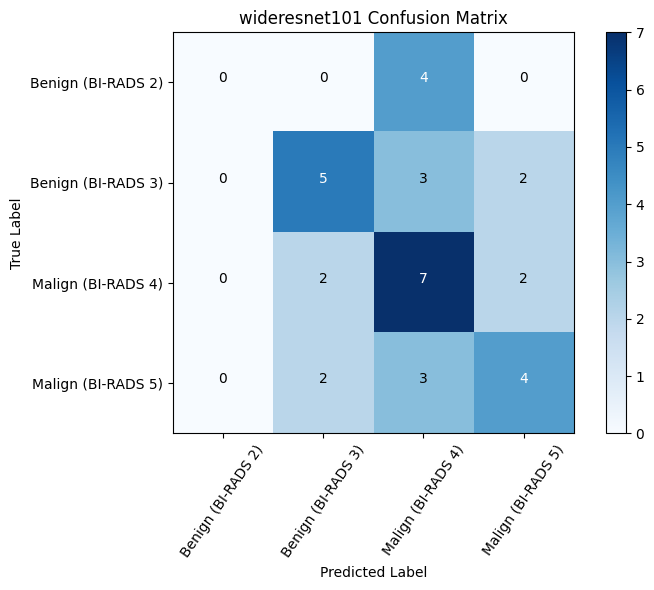

In [27]:
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

# Plot Function
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")

    print(cm)

    plt.figure(figsize=(8,6))

    plt.imshow(cm, interpolation='nearest', cmap=cmap)

    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))

    plt.xticks(
        tick_marks,
        classes,
        rotation=55
    )

    plt.yticks(
        tick_marks,
        classes
    )

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.

    for i, j in itertools.product(
        range(cm.shape[0]),
        range(cm.shape[1])
    ):
        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

# Class Names
cm_plot_label = [
    'Benign (BI-RADS 2)',
    'Benign (BI-RADS 3)',
    'Malign (BI-RADS 4)',
    'Malign (BI-RADS 5)'
]

# Plot
plot_confusion_matrix(
    cm,
    cm_plot_label,
    title='wideresnet101 Confusion Matrix'
)

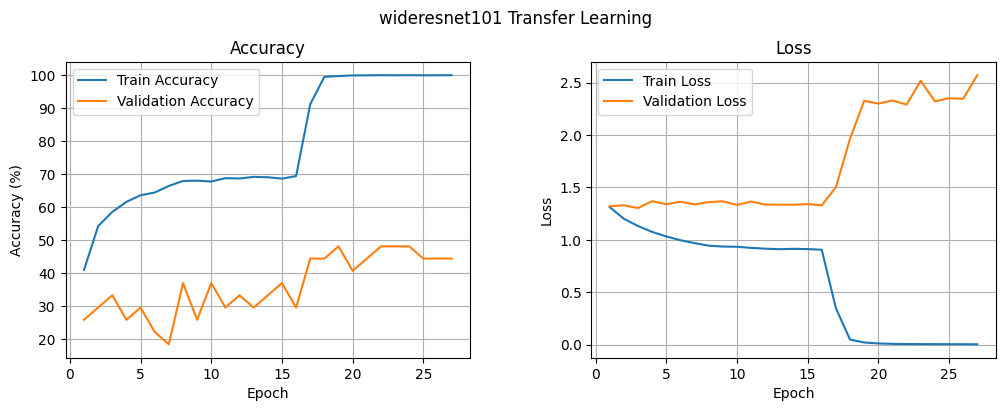

In [28]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

f.suptitle('wideresnet101 Transfer Learning',fontsize=12)
f.subplots_adjust(top=0.85,wspace=0.3)
epoch_list = range(1,len(train_accs) + 1)

# Accuracy
ax1.plot(epoch_list,train_accs,label='Train Accuracy')
ax1.plot(epoch_list,val_accs,label='Validation Accuracy')
ax1.grid()
ax1.set_ylabel('Accuracy (%)')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
ax1.legend(loc="best")

# Loss
ax2.plot(epoch_list,train_losses,label='Train Loss')
ax2.plot(epoch_list,val_losses,label='Validation Loss')
ax2.grid()
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
ax2.legend(loc="best")

plt.show()

In [29]:
import numpy as np
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef,mean_absolute_error,mean_squared_error,cohen_kappa_score)
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Class Names
target_names = [
    'Benign (BI-RADS 2)',
    'Benign (BI-RADS 3)',
    'Malign (BI-RADS 4)',
    'Malign (BI-RADS 5)'
]

print("Classification Report:")
print(classification_report(y_true,y_pred,target_names=target_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true,y_pred))
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true,y_pred,average='weighted')
recall = recall_score(y_true,y_pred,average='weighted')
f1 = f1_score(y_true,y_pred,average='weighted')
mcc = matthews_corrcoef(y_true,y_pred)
mae = mean_absolute_error(y_true,y_pred)
mse = mean_squared_error(y_true,y_pred)
kappa = cohen_kappa_score(y_true,y_pred)

# Print Metrics
print("\nAdditional Evaluation Metrics:")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-score       : {f1:.4f}")
print(f"MCC            : {mcc:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"MSE            : {mse:.4f}")
print(f"Cohen's Kappa  : {kappa:.4f}")

Classification Report:
                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.00      0.00      0.00         4
Benign (BI-RADS 3)       0.56      0.50      0.53        10
Malign (BI-RADS 4)       0.41      0.64      0.50        11
Malign (BI-RADS 5)       0.50      0.44      0.47         9

          accuracy                           0.47        34
         macro avg       0.37      0.40      0.37        34
      weighted avg       0.43      0.47      0.44        34

Confusion Matrix:
[[0 0 4 0]
 [0 5 3 2]
 [0 2 7 2]
 [0 2 3 4]]

Additional Evaluation Metrics:
Accuracy       : 0.4706
Precision      : 0.4290
Recall         : 0.4706
F1-score       : 0.4411
MCC            : 0.2507
MAE            : 0.7647
MSE            : 1.2353
Cohen's Kappa  : 0.2416


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [30]:
import matplotlib.pyplot as plt
n_classes = len(target_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
plt.figure(figsize=(8,8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i],pred[:,i])
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{target_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

NameError: name 'pred' is not defined

<Figure size 800x800 with 0 Axes>

In [ ]:
macro_auc = roc_auc_score(y_test_bin,pred,multi_class='ovr',average='macro')
weighted_auc = roc_auc_score(y_test_bin,pred,multi_class='ovr',average='weighted')
print(f"\nMacro AUC     : {macro_auc:.4f}")
print(f"Weighted AUC  : {weighted_auc:.4f}")